In [64]:
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [65]:
from Data_loading_from_excel import load_fish_data

In [66]:
df = load_fish_data("../Data/Raw/Main_Data.xlsx", sheet_name="Data edited")
pd.set_option('display.max_columns', None)
df.head()

,Date,Juilin Date,Month,Day,Year,row,Week,AM Feed,AM Transparency,PM Feed,PM Transparency,Stocked,Spring Temp (F),Max Spring (F),Min Spring (F),Daily turbi mean,Max daily turbi,Max air temp,Min air temp,Dec Rain,Calmar Rain,Year class,Strain,Lot,Sub Lot,Raceway,# fish,Morts,Fish Alive,Fish survival rate,Sub Lot % morts,Lot % mort,Strain % mort,Comments
0,2022-04-22,44673,4,22,2022,477,17,Y,5.450833,X,5.918333,NaN,46.7325,46.94,46.4,6.154271,9.9,64.0,37.0,0.67,0.61,2021,Arlee,ARA2,ARA2A2&A7A2,A2,10023,NaN,10023,100.0,0.0,0.0,0.0,NaN
1,2022-04-22,44673,4,22,2022,477,17,Y,5.450833,X,5.918333,NaN,46.7325,46.94,46.4,6.154271,9.9,64.0,37.0,0.67,0.61,2021,Shasta,STA3,STA3A3,A3,10010,NaN,10010,100.0,0.0,0.0,0.0,NaN
2,2022-04-22,44673,4,22,2022,477,17,Y,5.450833,X,5.918333,NaN,46.7325,46.94,46.4,6.154271,9.9,64.0,37.0,0.67,0.61,2021,Shasta,STA4,STA4A4,A4,10385,NaN,10385,100.0,0.0,0.0,0.0,NaN
3,2022-04-22,44673,4,22,2022,477,17,Y,5.450833,X,5.918333,NaN,46.7325,46.94,46.4,6.154271,9.9,64.0,37.0,0.67,0.61,2021,Shasta,STA4,STA4A5,A5,10595,NaN,10595,100.0,0.0,0.0,0.0,NaN
4,2022-04-22,44673,4,22,2022,477,17,Y,5.450833,X,5.918333,NaN,46.7325,46.94,46.4,6.154271,9.9,64.0,37.0,0.67,0.61,2021,Shasta,STA6,STA6A6,A6,7806,NaN,7806,100.0,0.0,0.0,0.0,NaN


In [67]:
#See number of rows and columns
df.shape

(28918, 34)

In [68]:
#See info about column names, non-null entries and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28918 entries, 0 to 28917
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                28918 non-null  datetime64[ns]
 1   Juilin Date         28918 non-null  int64         
 2   Month               28918 non-null  int64         
 3   Day                 28918 non-null  int64         
 4   Year                28918 non-null  int64         
 5   row                 28918 non-null  int64         
 6   Week                28918 non-null  int64         
 7   AM Feed             28757 non-null  object        
 8   AM Transparency     26616 non-null  float64       
 9   PM Feed             28722 non-null  object        
 10  PM Transparency     25933 non-null  float64       
 11  Stocked             18417 non-null  object        
 12  Spring Temp (F)     26754 non-null  float64       
 13  Max Spring (F)      9889 non-null   float64   

#### This shows that we have 9 columns that have object datatype which means they are categorical so we need to convert them into numerical valeus usng one hot encoding.

In [69]:
# Checking for missing valeus here
missing_values = df.isnull().sum()
print(missing_values)

Date                      0
Juilin Date               0
Month                     0
Day                       0
Year                      0
row                       0
Week                      0
AM Feed                 161
AM Transparency        2302
PM Feed                 196
PM Transparency        2985
Stocked               10501
Spring Temp (F)        2164
Max Spring (F)        19029
Min Spring (F)        19029
Daily turbi mean      19029
Max daily turbi       19029
Max air temp             60
Min air temp            117
Dec Rain                  0
Calmar Rain               0
Year class                0
Strain                    0
Lot                       0
Sub Lot                   0
Raceway                   0
# fish                    0
Morts                 15545
Fish Alive                0
Fish survival rate        0
Sub Lot % morts           0
Lot % mort                0
Strain % mort             0
Comments              27895
dtype: int64


#### This shows that we have 4 columns that have a lot of missign values (upto 19k) which makes them unsable. We have Two Columns (AM and PM Transparency) that have less missing valeus that we can fill out using KNN. We also have 4 columns (AM and PM Feed, Max air temp, Min air temp) that have very few missign values, we can fill these out using google and impute zero.

In [70]:
print(f"Number of duplicates: {df.duplicated().sum()}")


Number of duplicates: 0


#### This shows that we don't have any duplicates which makes the data a lot more reliable as there is no bias.

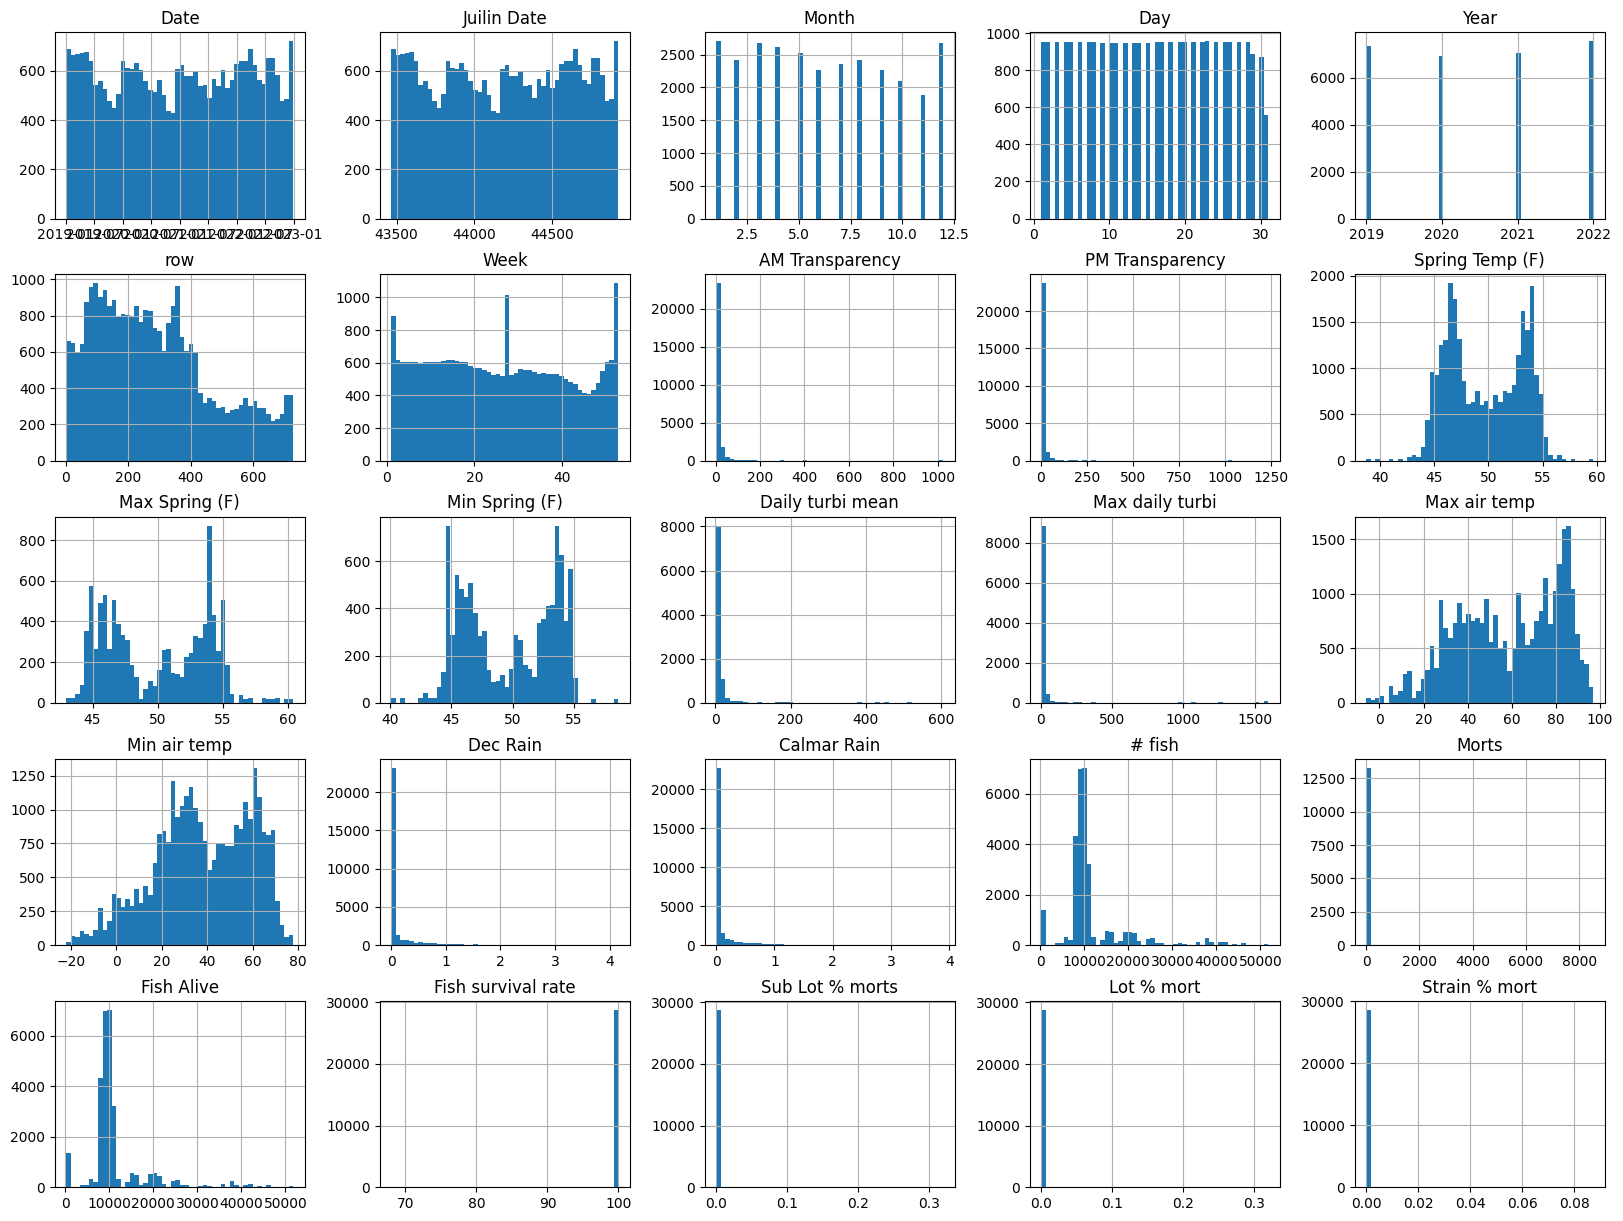

In [81]:
df.hist(figsize=(20, 15), bins=50)
plt.show()


### The data shows seasonal variations in temperature-related variables, with bimodal distributions indicating different seasonal clusters. Water quality metrics (e.g., turbidity, transparency) are right-skewed, meaning low values are common, but occasional spikes occur. Fish survival rates are generally high, with most mortality-related metrics remaining low, though some extreme cases exist. Rainfall is mostly low, with a few heavy-rain events. The time-based variables (date, month, day, year) appear uniformly distributed, suggesting consistent data collection over time.# Testing purpose